![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
#np.random.seed(42)
#y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

# Guardar predicciones en formato exigido en la competencia de kaggle
#y_pred.to_csv('test_submission_file.csv', index_label='ID')
#y_pred.head()

In [ ]:
# Importación librerías
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import Markdown, display
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
from flask import Flask
from flask_restx import Api, Resource, fields
import joblib

warnings.filterwarnings('ignore')

In [ ]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

#Eliminar variables que no vamos a usar
TrainingDrop = [dataTraining.columns[0], 'Unnamed: 0', 'track_id']
data_Training = dataTraining.drop(columns=TrainingDrop)

TestDrop = [dataTesting.columns[0], 'track_id']
data_Testing = dataTesting.drop(columns=TestDrop)

# 1. Preprocesamiento de datos

## 1.1 Validación Valores Nulos

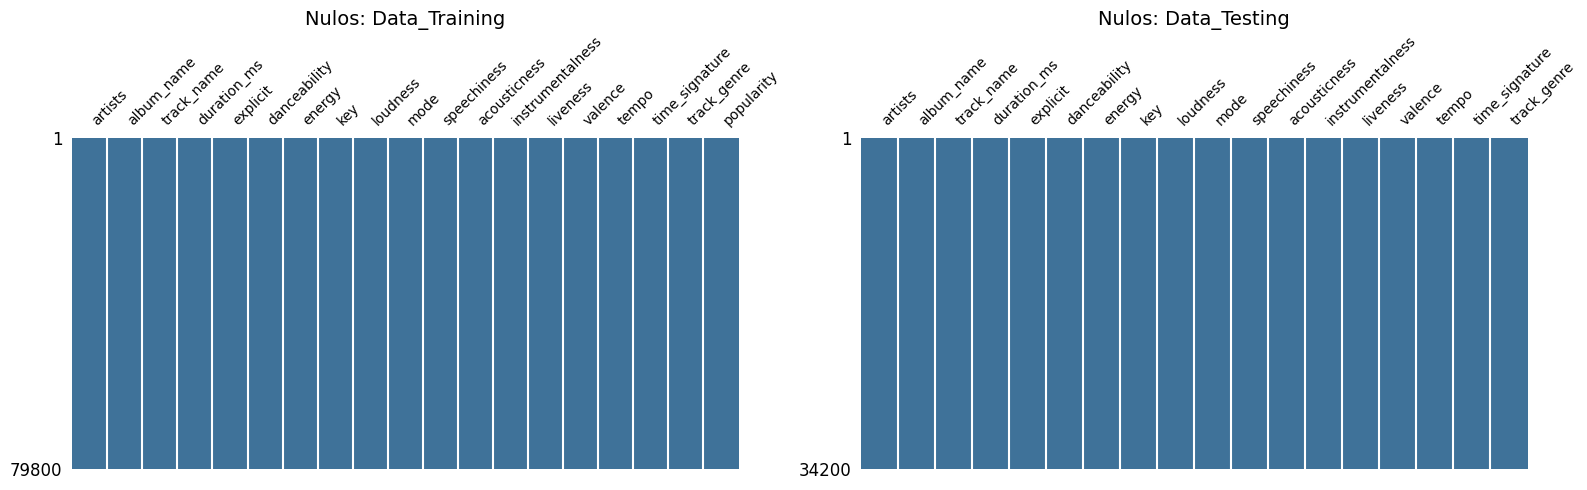

Se tienen 0 valores nulos en los datos de Training 

Se tienen 3 valores nulos en los datos de Testing 

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
7668,NaN,NaN,NaN,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Los valores nulos encontrados, se corrigen para mostrar ***Unknown***

Los nuevos valores nulos para los datos de Testing son 0 

In [ ]:
#Se validan nulos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(data_Training, ax=ax[0], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[0].set_title("Nulos: Data_Training", fontsize=14)
msno.matrix(data_Testing, ax=ax[1], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[1].set_title("Nulos: Data_Testing", fontsize=14)
plt.tight_layout()
plt.show()

null_Training = data_Training.isnull().sum().sum()
nulos_Training = data_Training[data_Training.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Training} valores nulos en los datos de Training """))
null_Testing = data_Testing.isnull().sum().sum()

nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Testing} valores nulos en los datos de Testing """))
display(nulos_Testing)

display(Markdown(f"""Los valores nulos encontrados, se corrigen para mostrar ***Unknown***"""))
data_Testing['artists'] = data_Testing['artists'].fillna('Unknown')
data_Testing['album_name'] = data_Testing['album_name'].fillna('Unknown')
data_Testing['track_name'] = data_Testing['track_name'].fillna('Unknown')

null_Testing = data_Testing.isnull().sum().sum()
nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Los nuevos valores nulos para los datos de Testing son {null_Testing} """))

## 1.2 Revisión Comportamiento y valores de las variables

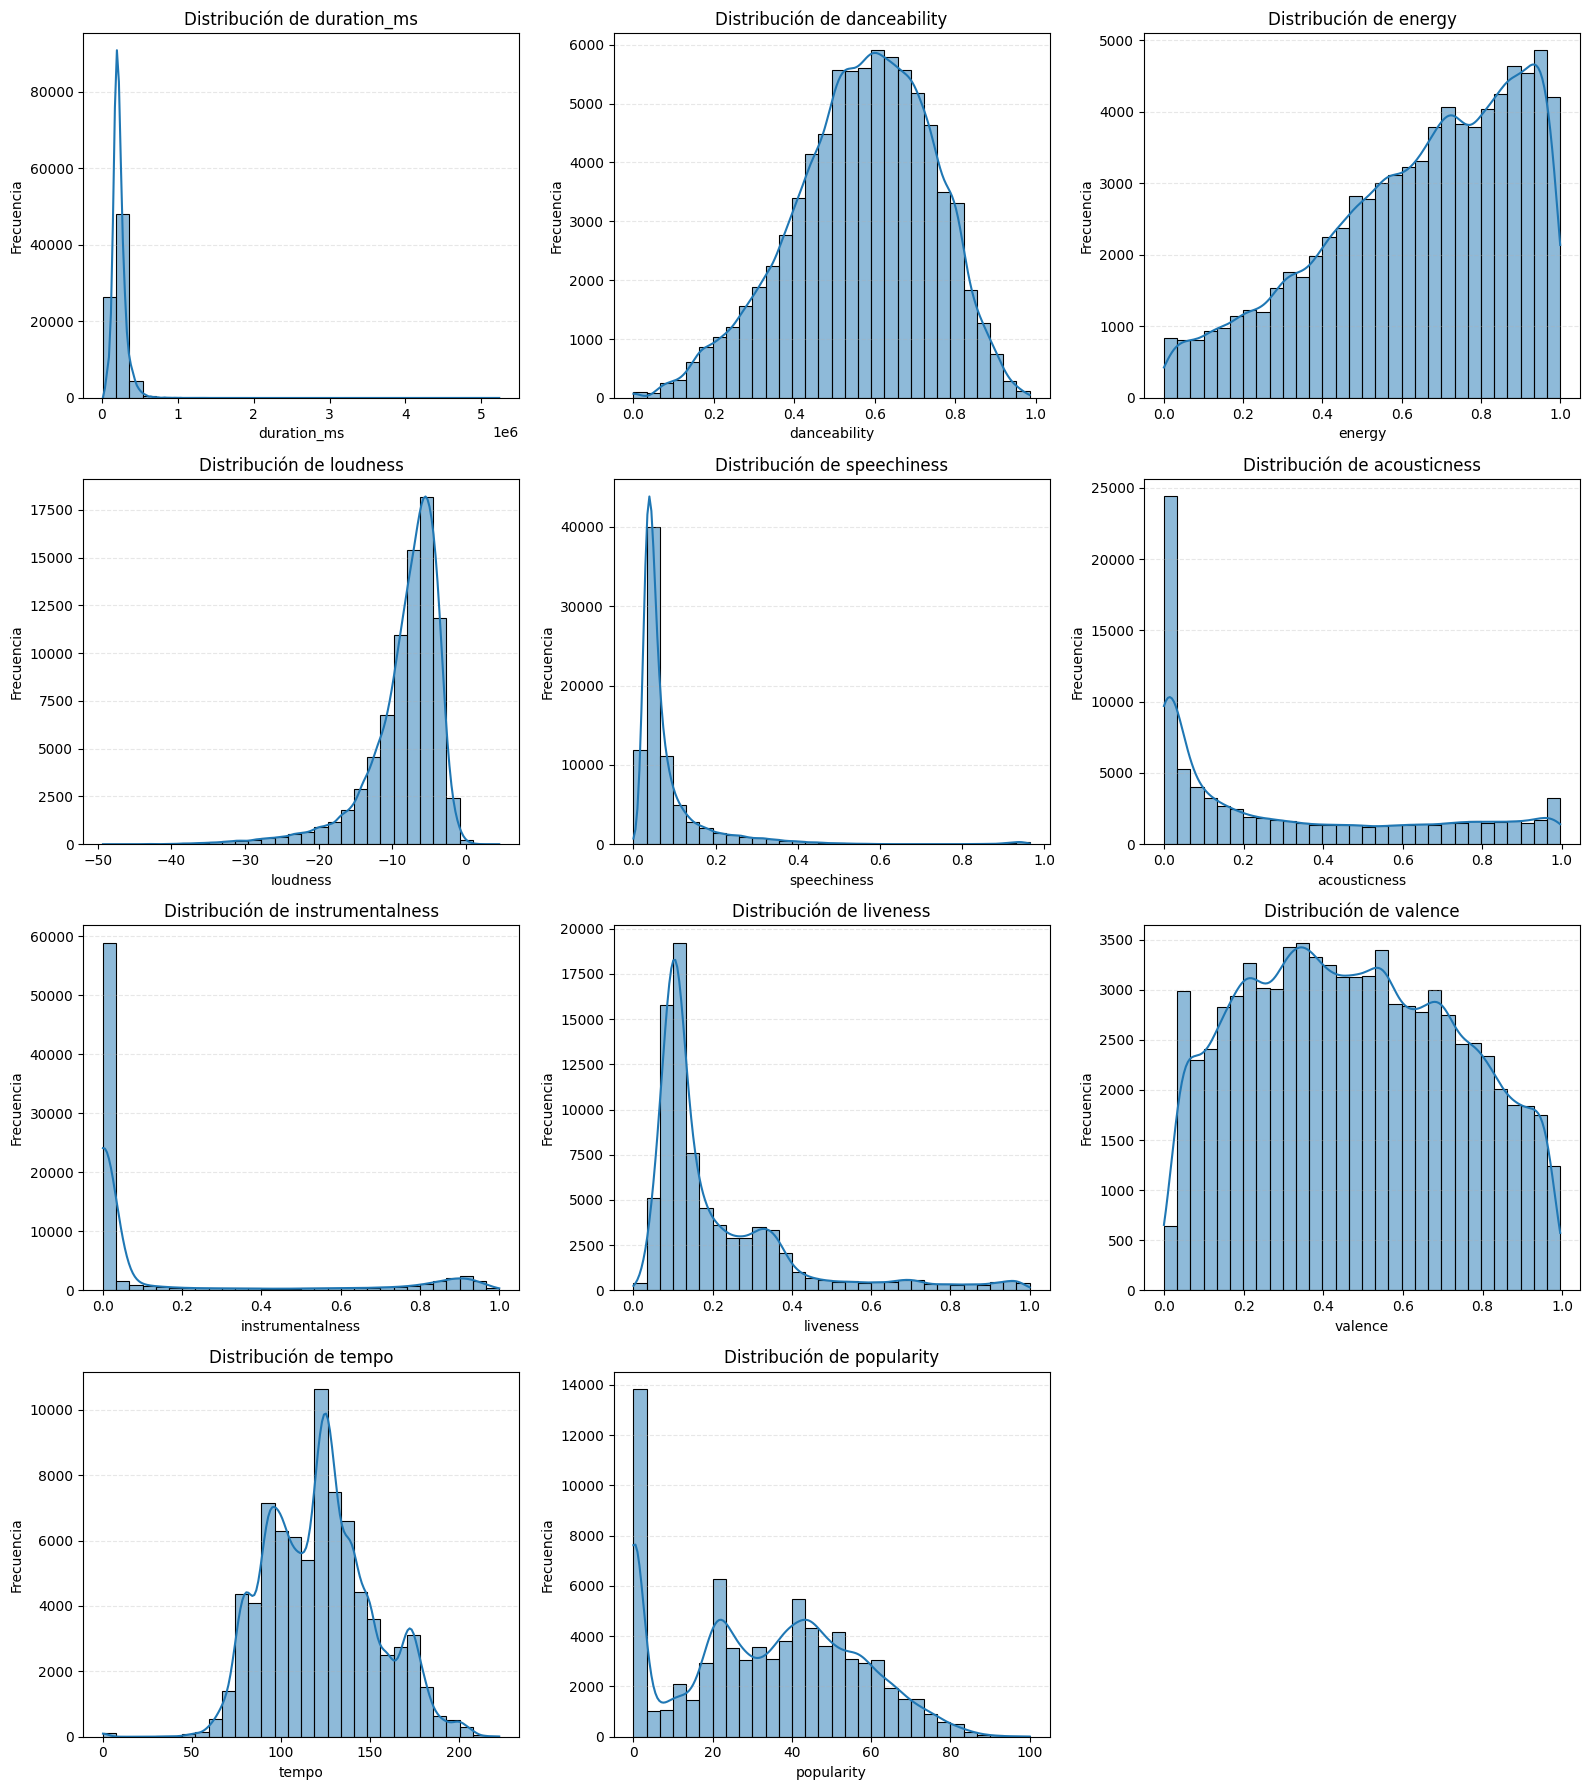

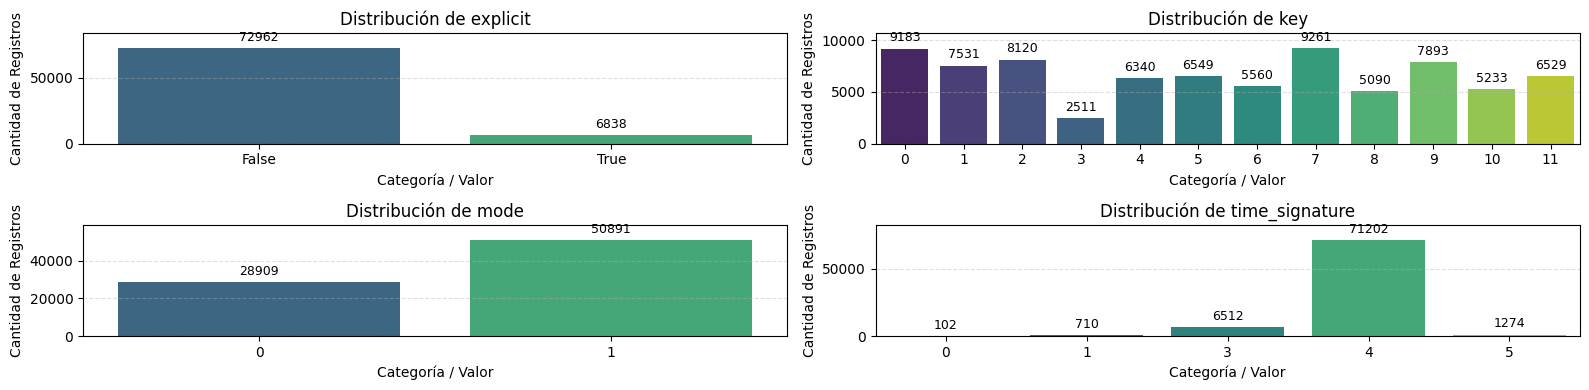

KeyboardInterrupt: 

In [ ]:
#Se clasifican las variables de acuerdo a su tipo
def clasificar_variables(df):
    variables_numericas = []
    variables_categoricas = []
    variables_binarias = []
    
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            variables_categoricas.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= 12: #Numero de valores de 'key'
                variables_binarias.append(col)
            else:
                variables_numericas.append(col)
            
    return variables_numericas, variables_categoricas, variables_binarias

var_numericas, var_categoricas, vars_bin = clasificar_variables(data_Training)

#Vemos el comportamiento de las varaiables numericas
plt.figure(figsize=(16, 18))
for i, var in enumerate(var_numericas):
    plt.subplot((len(var_numericas) + 2) // 3, 3, i + 1)
    sns.histplot(dataTraining[var], kde=True, bins=30)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#Vemos el comportamiento de las varaiables binarias
plt.figure(figsize=(16, 10))
for i, var in enumerate(vars_bin):
    ax = plt.subplot(2, 2, i + 1)
    sns.countplot(data=dataTraining, x=var, palette='viridis', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.title(f'Distribución de {var}', fontsize=12)
    plt.xlabel('Categoría / Valor')
    plt.ylabel('Cantidad de Registros')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

#Vemos el comportamiento de las varaiables categóricas - top 20
plt.figure(figsize=(16, 10))
for i, var in enumerate(var_categoricas):
    ax = plt.subplot(2, 2, i + 1)
    sns.countplot(data=dataTraining, x=var, palette='viridis', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.title(f'Distribución de {var}', fontsize=12)
    plt.xlabel('Categoría / Valor')
    plt.ylabel('Cantidad de Registros')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

## 1.3 Análisis mediante correlación - Mapa de calor

In [ ]:
# Hacemos un mapa de calor de las variables numericas para poder ver las correlaciones entre ellas
plt.figure(figsize=(35, 20))
sns.heatmap(dataTraining[var_numericas].corr(), annot=True, cmap = "coolwarm", fmt=".3f", linewidths = 0.5)
plt.title("Mapa de Calor de Correlaciones (Set de datos de Training)")
plt.show()

# Se puede observar que las variables energy - loudenss y acousticness - energy tiene correlaciones altas con valores de 0.7 y -0.7 respectivamente, las cuales se deciden dejar como están
# dado que no representan un problema para modelos basados en árboles de decisión. 

## 1.4 Análisis de estadísticas descriptivas

In [ ]:
# Mostramos las estadísticas descriptivas de las variables del set de datos de Train
pd.set_option('display.max_columns', None)
display(dataTraining.describe())

# La variable duration_ms tiene una escala muy grande, la cual puede generar problemas para algunos modelos (por ejemplo regresiones lineales), por lo que se pasa a minutos
dataTraining['duration_min'] = dataTraining['duration_ms'] / 60000
data_Testing['duration_min'] = data_Testing['duration_ms'] / 60000

# Eliminamos la columna original duration_ms
dataTraining.drop(columns=['duration_ms'], inplace=True)
data_Testing.drop(columns=['duration_ms'], inplace=True)

pd.set_option('display.max_columns', None)
display(dataTraining.describe())

## 1.5 Ingeniería de Variables

In [ ]:
#Creamos una vriable binaria que nos dice si la canción es de una colaboración o no: 1 si contiene ';', 0 si no.
data_Training['is_collaboration'] = data_Training['artists'].str.contains(';').astype(int)
data_Testing['is_collaboration'] = data_Testing['artists'].str.contains(';').astype(int)

# Convertimos a valores numericos los valores de la columna explicit
data_Training['explicit'] = data_Training['explicit'].astype(int)
data_Testing['explicit'] = data_Testing['explicit'].astype(int)

# Se dividen los datos en predictores y variable de interés
y_Training = data_Training['popularity']
X_Training = data_Training.drop(['popularity'], axis=1)

# Se dividen los datos de Training en Train y Validation
X_train, X_val, y_train, y_val = train_test_split(X_Training, y_Training, test_size=0.2, random_state=42)

In [ ]:
# Creamos una variable que contenga el promedio de la popularidad por artista
# Para los casos en donde hay colaborciones, se "duplica" la columna, teniendo cada artista en una fila nueva y así calculando el promedio de popularidad de una mejor manera
train_exploded = X_train[['artists']].assign(artists=X_train['artists'].str.split(';')).explode('artists')
train_exploded['popularity'] = y_train 

# Se calcula el promedio de popularidad por artista
diccionario_artistas = train_exploded.groupby('artists')['popularity'].mean()
display(diccionario_artistas.head())

# Se calcula el promedio de popularidad general
global_mean = y_train.mean()

# Se asigna la popularidad promedio a cada artista como un valor en nueva columna. Se tienen 3 casos:
# 1. La canción pertencene a solo un artista, por lo que busca su popularidad promedio y se asigna ese valor
# 2. La canción pertence a más de un artista, por lo que sebusca la popularidad de cada artista de la colaboración y se promedia el resultado
# 3. La canción pertence a un artista que no esta en el set de datos de Train, para esos casos, se asigna el promedio global
                                                                                                      
def obtener_fama(lista_artistas):
    popularidad = [diccionario_artistas.get(a.strip(), global_mean) for a in lista_artistas]
    return sum(popularidad) / len(popularidad)

X_train['artist_popularity_avg'] = X_train['artists'].str.split(';').apply(obtener_fama)
X_val['artist_popularity_avg'] = X_val['artists'].str.split(';').apply(obtener_fama)
data_Testing['artist_popularity_avg'] = data_Testing['artists'].str.split(';').apply(obtener_fama)

#Se elimina la columna original de artista
X_train.drop(columns=['artists'], inplace=True)
X_val.drop(columns=['artists'], inplace=True)
data_Testing.drop(columns=['artists'], inplace=True)

display(Markdown(f"""Las traformaciones realizadas no generan data-leakage dentro dentro de los datos dado que algunas de ellas no contemplan la variable de interés dentro de
                los calculos, y otras como artist_popularity_avg la consideran pero solo usan los datos de entrenamiento, por lo que cuando se entrene un modelo, los datos de 
                 validación y test no conocerán el comportamiento de la variable a predecir."""))

artists
!nvite                                         23.0
"Cats" 1983 Broadway Cast                      26.5
"Pepo" San Martín                              21.0
"Puppy Dog Pals" Cast                          55.0
"The Phantom Of The Opera" 1990 German Cast    24.0
Name: popularity, dtype: float64

In [ ]:
display(Markdown(f"""Para el análisis se usarán dos set de datos (A y B), cada uno con variaciones distintas, para poder obervar el impacto en las métricas de los modelos a 
                 entrenar y así poder definir cual de los dos se usará para la calibración del modelo final a implementar.."""))

#Set de datos A
X_train_A = X_train.copy()
X_val_A = X_val.copy()
x_test_A = data_Testing.copy()

#Set de datos B
X_train_B = X_train.copy()
X_val_B = X_val.copy()
x_test_B = data_Testing.copy()

## 1.5.1 Set de datos A

In [ ]:
display(Markdown(f"""Para el set de datos A, se haran 2 transformaciones; eliminación de variables categóricas y división de la variable genero en multiples variables, una por 
                 cada genero (posible agrpación de generos dependiendo de los valores y frecuencias)."""))

#Eliminamos las variales categoricas
X_train_A = X_train_A.drop(columns=['track_name', 'album_name'])
X_val_A = X_val_A.drop(columns=['track_name', 'album_name'])
X_test_A = X_test_A.drop(columns=['track_name', 'album_name'])

# Creamos una variable para cada genero, para poder separar el impacto por género
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
train_enc = encoder.fit_transform(X_train_A[['track_genre']])
val_enc = encoder.transform(X_val_A[['track_genre']])
test_enc = encoder.transform(x_test_A[['track_genre']])
cols = encoder.get_feature_names_out(['track_genre'])
X_train_A = pd.concat([X_train_A.drop(columns='track_genre'), pd.DataFrame(train_enc, columns=cols, index=X_train_A.index)], axis=1)
X_val_A = pd.concat([X_val_A.drop(columns='track_genre'), pd.DataFrame(val_enc, columns=cols, index=X_val_A.index)], axis=1)
x_test_A = pd.concat([x_test_A.drop(columns='track_genre'), pd.DataFrame(test_enc, columns=cols, index=x_test_A.index)], axis=1)

# Eliminamos la columna original porque ya no la necesitamos
X_train_A.drop(columns=['track_genre'], inplace=True)
X_val_A.drop(columns=['track_genre'], inplace=True)
x_test_A.drop(columns=['track_genre'], inplace=True)

# Después de crear las variables para cada genero se observa la representatividad de cada una dentro del dataset para poder evaluar si es pertinente agrupar generos
generos_cols = [col for col in X_train_A.columns if col.startswith('G_')]
frecuencias = X_train_A[generos_cols].sum().sort_values(ascending=False)
display(frecuencias.head())
display(frecuencias.tail())

plt.figure(figsize=(8, 4))
plt.plot(range(len(frecuencias)), frecuencias.values, marker='o', linestyle='--')
plt.title("Número de canciones por género")
plt.xlabel("Índice del Género")
plt.ylabel("Número de canciones")
plt.grid(True)
plt.show()
# Se observa que los generos tienen entre 524 a 594  filas dntro del dataset de train, por lo cual se tiene un buen balanceo de generos y se mantendrá la información como ya 
# se tiene

display(X_train_A.head())

## 1.5.2 Set de datos B

In [ ]:
display(Markdown(f"""Para el set de datos B, se dejarán las variables categóricas y el tratamiento de estas será distinto, dado que a todas se les aplicará un Frequency 
                 encoding."""))

mapas_frecuencias = {}

for col in var_categoricas:
    freq_map = X_train_B[col].value_counts(normalize=True).to_dict()
    mapas_frecuencias[col] = freq_map
    X_train_B[col + '_freq'] = X_train_B[col].map(freq_map)

#Aplicamos los cambios a Val y Test usando los datos de entrenamiento
for col in var_categoricas:
    X_val_B[col + '_freq'] = X_val_B[col].map(mapas_frecuencias[col])
    X_val_B[col + '_freq'] = X_val_B[col + '_freq'].fillna(0) # Si el genero es nuevo, se le pone 0

    X_test_B[col + '_freq'] = X_test_B[col].map(mapas_frecuencias[col])
    X_test_B[col + '_freq'] = X_test_B[col + '_freq'].fillna(0) # Si el genero es nuevo, se le pone 0

X_train_B.drop(columns=var_categoricas, inplace=True)
X_val_B.drop(columns=var_categoricas, inplace=True)
X_test_B.drop(columns=var_categoricas, inplace=True)

display(X_train_B.head())

# 2. Definición y calibración del modelo

In [ ]:
#Se validan los resultados obtenidos por varios modelos basados en arboles para cada set de datos (A y B)

modelos = {
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "Bagging": BaggingRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}

datos = {
    "Set_A": (X_train_A, X_val_A),
    "Set_B": (X_train_B, X_val_B)
}

mse_val = {}
for datos, (X_tr, X_val) in datos.items():
    for nombre, modelo in modelos.items():
        modelo.fit(X_tr, y_train)
        y_pred = modelo.predict(X_val)
        mse = mean_squared_error(y_val, y_pred) 
        mse_val[f"{nombre}_{datos}"] = mse

df_mse_val = pd.DataFrame(list(mse_val.items()), columns=['Modelo_Set', 'MSE'])

# Separamos el nombre del modelo y el set de datos para la gráfica
df_mse_val[['Modelo', 'Dataset']] = df_mse_val['Modelo_Set'].str.split('_Set_', expand=True)
df_mse_val['Dataset'] = 'Set ' + df_mse_val['Dataset']

plt.figure(figsize=(12, 6))
sns.barplot(data=df_mse_val, x='Modelo', y='MSE', hue='Dataset', palette='magma')

plt.title('Comparación de MSE: Preprocesamiento A vs B', fontsize=15)
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()